# 📌 Project Title

### Sentiment Analysis of Customer Reviews in E-Commerce Platforms Using Machine Learning

<h1 align="center">Sentiment Analysis</h1>

<p align="center">
  <img src="images/sentiment.png" width="900">
</p>

# 📖 Introduction

##### With the rapid growth of online shopping platforms, customers increasingly rely on reviews and ratings before making purchase decisions. E-commerce websites generate massive amounts of textual feedback daily, making it difficult for businesses to manually analyze customer opinions.

##### Sentiment Analysis, a subfield of Natural Language Processing (NLP), enables automated extraction of customer sentiments (positive, negative, or neutral) from textual reviews. By applying machine learning techniques such as TF-IDF vectorization and classification algorithms (e.g., Logistic Regression, Naïve Bayes, or Support Vector Machines), this project aims to classify customer reviews based on their sentiment.

##### The insights derived from this analysis help businesses understand customer satisfaction levels, improve product quality, enhance service strategies, and make data-driven decisions.

# 🎯 Objectives of the Project

##### 1)To collect and preprocess customer review data from an e-commerce platform.

##### 2)To perform text cleaning and transformation using NLP techniques.

##### 3)To convert textual data into numerical features using TF-IDF vectorization.

##### 4)To build and train machine learning models for sentiment classification.

##### 5)To evaluate model performance using accuracy, confusion matrix, and classification metrics.

##### 6)To categorize reviews into sentiment classes (Positive, Negative, Neutral).

##### 7)To provide meaningful insights for business decision-making based on sentiment trends.

# ❗ Problem Statement

##### E-commerce platforms receive thousands of customer reviews daily. Manually analyzing these reviews to understand customer sentiment is time-consuming, inefficient, and impractical at scale. Without automated sentiment classification, businesses may fail to quickly identify negative feedback, recurring complaints, or positive trends.

##### Therefore, there is a need for an automated system that can accurately classify customer reviews into sentiment categories using machine learning techniques. This project aims to develop a sentiment analysis model that processes textual reviews and predicts their sentiment, enabling businesses to respond proactively and enhance customer satisfaction.

# Import Tools

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# LOAD DATASET

In [37]:
df = pd.read_excel(r"E:\BA BI\Project BBC\project3\Sentiment_Analysis\Review.xlsx")
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
10995,10996,B001NJI7GQ,AGITSM4KNGD73,Jeanne H. Kingsland,4,4,5,1279324800,Ambrosia.,"My daughter, living and working in DC this sum..."
10996,10997,B001NJI7GQ,A1P1DYV98MBXM4,C. Moeller,5,6,5,1299024000,Great coconut water in just the right size!,This has been my favorite brand of coconut wat...
10997,10998,B001NJI7GQ,AK5KVP6NX83XL,Elizabeth Urick,2,2,4,1297641600,Great coconut water in just the right size!,I like the slight pineapple flavor in this bet...
10998,10999,B001NJI7GQ,A2N2UYF083BZW0,"Hydrangea ""hydrangea""",1,1,4,1327363200,Great coconut water in just the right size!,Love this juice. Scheduled shipment is conveni...


# Data Cleaning Process

In [38]:
df.shape
df['Summary'].value_counts()

Summary
Delicious                                47
Yummy!                                   41
Delicious!                               39
Great                                    26
Great product                            25
                                         ..
Damn this is a hot sauce!                 1
Definitely the FINAL answer (for now)     1
The final answer indeed!                  1
the other reviews are right!              1
Da Bomb: The Final Answer?  Yes.          1
Name: count, Length: 9350, dtype: int64

In [39]:
df = df.drop([
    "Id",
    "ProductId",
    "UserId",
    "ProfileName",
    "HelpfulnessNumerator",
    "HelpfulnessDenominator",
    "Time"
], axis=1)
df

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...
10995,5,Ambrosia.,"My daughter, living and working in DC this sum..."
10996,5,Great coconut water in just the right size!,This has been my favorite brand of coconut wat...
10997,4,Great coconut water in just the right size!,I like the slight pineapple flavor in this bet...
10998,4,Great coconut water in just the right size!,Love this juice. Scheduled shipment is conveni...


### Column Explanation (Short Form)

#### Score → Rating given by the customer (1 to 5)

##### 1–2 = Negative

##### 3 = Neutral

##### 4–5 = Positive

#### Summary → Short title of the review

#### Text → Full detailed customer review

## 👉 In NLP projects, Summary and Text is the main input feature, and Score is usually the target (label) for training the sentiment classification model.

In [40]:
def convert_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['Score'].apply(convert_sentiment)
df

,Score,Summary,Text,sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,2,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,Great taffy,Great taffy at a great price. There was a wid...,Positive
...,...,...,...,...
10995,5,Ambrosia.,"My daughter, living and working in DC this sum...",Positive
10996,5,Great coconut water in just the right size!,This has been my favorite brand of coconut wat...,Positive
10997,4,Great coconut water in just the right size!,I like the slight pineapple flavor in this bet...,Positive
10998,4,Great coconut water in just the right size!,Love this juice. Scheduled shipment is conveni...,Positive


In [41]:
df.duplicated().sum()

np.int64(501)

In [42]:
df = df.drop_duplicates()

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.dtypes

Score         int64
Summary      object
Text         object
sentiment    object
dtype: object

In [45]:
df.isnull().sum()

Score        0
Summary      0
Text         0
sentiment    0
dtype: int64

In [46]:
df.shape

(10499, 4)

In [47]:
a=df["sentiment"].value_counts()
a

sentiment
Positive    8042
Negative    1593
Neutral      864
Name: count, dtype: int64

# Exploratory Data Analysis

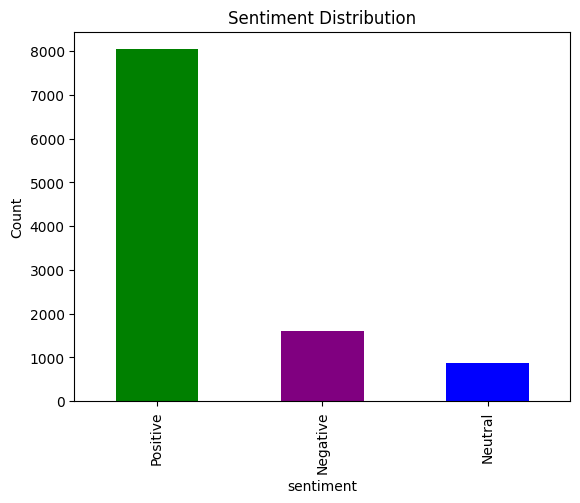

In [48]:
a.plot(kind='bar', color=['green', 'purple', 'blue', 'orange', 'red'])
plt.title("Sentiment Distribution")
plt.xlabel("sentiment")
plt.ylabel("Count")
plt.show()

In [49]:
l=("Positive", "Neutral", "Negative")
l

('Positive', 'Neutral', 'Negative')

In [50]:
ex=(0.3,0,0)

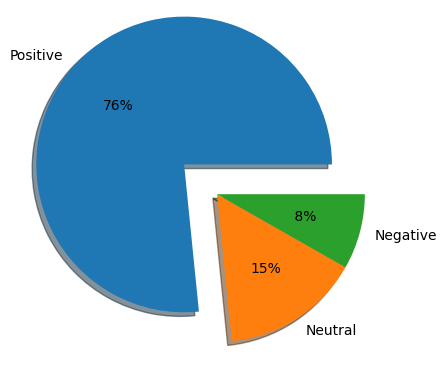

In [51]:
plt.pie(a.values,labels=l,explode=ex,shadow=True,autopct="%2.d%%")
plt.show()

# Machine Learning Model To Use Get Right Accuracy

In [52]:
le=LabelEncoder()
df["sentiment"]=le.fit_transform(df["sentiment"])
df

C:\Users\hansa\AppData\Local\Temp\ipykernel_21172\548163584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"]=le.fit_transform(df["sentiment"])


,Score,Summary,Text,sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,2
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,2
3,2,Cough Medicine,If you are looking for the secret ingredient i...,0
4,5,Great taffy,Great taffy at a great price. There was a wid...,2
...,...,...,...,...
10993,4,Very Good Espresso,This espresso coffee is an excellent coffee. ...,2
10994,5,Best Espresso Ever,Just used this product in my DeLonghi EC702. B...,2
10997,4,Great coconut water in just the right size!,I like the slight pineapple flavor in this bet...,2
10998,4,Great coconut water in just the right size!,Love this juice. Scheduled shipment is conveni...,2


In [53]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [54]:
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['Text'].apply(clean_text)
df['clean_summary'] = df['Summary'].apply(clean_text)

C:\Users\hansa\AppData\Local\Temp\ipykernel_21172\1121546694.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['Text'].apply(clean_text)
C:\Users\hansa\AppData\Local\Temp\ipykernel_21172\1121546694.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_summary'] = df['Summary'].apply(clean_text)


In [55]:
df["clean_text"]

0        bought sever vital can dog food product found ...
1        product arriv label jumbo salt peanut peanut a...
2        confect around centuri light pillowi citru gel...
3        look secret ingredi robitussin believ found go...
4        great taffi great price wide assort yummi taff...
                               ...                        
10993    espresso coffe excel coffe wonder head great f...
10994    use product delonghi ec best cup espresso gott...
10997    like slight pineappl flavor better plain cocon...
10998    love juic schedul shipment conveni econom expe...
10999    tri everi brand coconut water health food stor...
Name: clean_text, Length: 10499, dtype: object

In [56]:
df["clean_summary"]

0                 good qualiti dog food
1                              advertis
2                           delight say
3                         cough medicin
4                           great taffi
                      ...              
10993                     good espresso
10994                best espresso ever
10997    great coconut water right size
10998    great coconut water right size
10999    great coconut water right size
Name: clean_summary, Length: 10499, dtype: object

In [57]:
df['final_text'] = df['clean_text'].fillna('') + " " + df['clean_summary'].fillna('')

C:\Users\hansa\AppData\Local\Temp\ipykernel_21172\1507734244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['final_text'] = df['clean_text'].fillna('') + " " + df['clean_summary'].fillna('')


In [58]:
x = df['final_text']
y = df['sentiment']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42)

In [59]:
tfidf = TfidfVectorizer(max_features=3000,ngram_range=(1,2),min_df=2,max_df=0.9)
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)


In [60]:
print(type(x_train))
print(x_train.shape)
print(x_train_tfidf.shape)

<class 'pandas.core.series.Series'>
(7349,)
(7349, 3000)


In [61]:
#x_train_tfidf = x_train_tfidf.astype('float32')

In [62]:
model = LogisticRegression(class_weight='balanced',max_iter=1000,solver='lbfgs')
model.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [63]:
y_pred = model.predict(x_test_tfidf)

In [64]:
acc=accuracy_score(y_test, y_pred)
cc=confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
acc

              precision    recall  f1-score   support

           0       0.58      0.71      0.64       496
           1       0.29      0.44      0.35       271
           2       0.94      0.84      0.89      2383

    accuracy                           0.79      3150
   macro avg       0.60      0.66      0.63      3150
weighted avg       0.83      0.79      0.80      3150



0.7857142857142857

In [65]:
model2 = MultinomialNB()
model.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [66]:
y_predict = model.predict(x_test_tfidf)

In [67]:
acc=accuracy_score(y_test, y_predict)
cc=confusion_matrix(y_test, y_predict)
print(classification_report(y_test, y_predict))
acc

              precision    recall  f1-score   support

           0       0.58      0.71      0.64       496
           1       0.29      0.44      0.35       271
           2       0.94      0.84      0.89      2383

    accuracy                           0.79      3150
   macro avg       0.60      0.66      0.63      3150
weighted avg       0.83      0.79      0.80      3150



0.7857142857142857

In [68]:
model3 = LinearSVC()
model.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [69]:
y_pred = model.predict(x_test_tfidf)

In [70]:
acc=accuracy_score(y_test, y_pred)
cc=confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
acc

              precision    recall  f1-score   support

           0       0.58      0.71      0.64       496
           1       0.29      0.44      0.35       271
           2       0.94      0.84      0.89      2383

    accuracy                           0.79      3150
   macro avg       0.60      0.66      0.63      3150
weighted avg       0.83      0.79      0.80      3150



0.7857142857142857

# Import Pickle File

In [71]:
import pickle

model_path = r"E:\BA BI\Project BBC\project3\Sentiment_Analysis\sentiment_model.pkl"
model_path_1 = r"E:\BA BI\Project BBC\project3\Sentiment_Analysis\tfidf_vectorizer.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(model_path_1, 'wb') as f:
    pickle.dump(tfidf, f)

print("Model saved successfully at:", model_path)

Model saved successfully at: E:\BA BI\Project BBC\project3\Sentiment_Analysis\sentiment_model.pkl
